
<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/6-Regression.ipynb)

</div>


$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE -- REGRESSION}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{Oct 10, 2025}\\\\\\
\end{array}
$$

---

**Goals for Today**

1. Introduction
2. Descriptive Regression
    - Identifiction
    - Interpretation
3. Causal Regression
    - Identification


# Introduction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
ads = pd.read_csv(url)
ads.head()


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


| Variable | Description | Units |
|-----------|--------------|--------|
| **TV** | Advertising budget spent on **TV commercials** | Thousands of dollars ($000s) |
| **Radio** | Advertising budget spent on **radio commercials** | Thousands of dollars ($000s) |
| **Newspaper** | Advertising budget spent on **newspaper ads** | Thousands of dollars ($000s) |
| **Sales** | Product **sales** in that market | Thousands of units sold |

In [3]:
# --- Interactive plot ---
def plot_line(beta_0=0, beta_1=0):
    plt.figure(figsize=(8, 6))
    
    # Scatter plot (actual data)
    plt.scatter(ads["TV"], ads["sales"], color="steelblue", alpha=0.7, label="Observed Data (Y)")
    
    # Regression line (predicted values)
    x_vals = ads["TV"]
    y_vals = beta_0 + beta_1 * x_vals
    plt.plot(x_vals, y_vals, color="red", linewidth=2, label=f"Predicted Line: $\hat{{y}} = {beta_0:.1f} + {beta_1:.2f}x$")
    
    plt.xlabel("TV Advertising Spend ($000s)", fontsize=12)
    plt.ylabel("Sales (1000 units)", fontsize=12)
    plt.title("Choosing a Regression Line by Changing β₀ and β₁", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Sliders for β₀ and β₁
interact(
    plot_line,
    beta_0=FloatSlider(min=0, max=10, step=0.5, value=5, description="β₀ (intercept)"),
    beta_1=FloatSlider(min=-0.1, max=0.2, step=0.01, value=0.05, description="β₁ (slope)")
)


interactive(children=(FloatSlider(value=5.0, description='β₀ (intercept)', max=10.0, step=0.5), FloatSlider(va…

<function __main__.plot_line(beta_0=0, beta_1=0)>

**Problems W/ choosing the beta visually:**
1. Too hand-wavey
2. Does not scale to higher dimesions

**Goal:** Develop a way to algorithmically find the "best" betas $\beta_0, \beta_1, ..., \beta_n$

The goal of linear regression is to find the parameters that minimize the *sum of squared residuals*:

$$
\hat{\beta}_0, \hat{\beta}_1 = \underset{\beta_0, \beta_1}{\arg\min} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2
$$

Since $\hat{Y}_i = \beta_0 + \beta_1 X_i$, this becomes:

$$
\hat{\beta}_0, \hat{\beta}_1 = \underset{\beta_0, \beta_1}{\arg\min} \sum_{i=1}^{n} (Y_i - (\beta_0 + \beta_1 X_i))^2
$$


In [4]:
def plot_line(beta_0=0, beta_1=0):
    plt.figure(figsize=(8, 6))
    
    # Scatter plot
    plt.scatter(ads["TV"], ads["sales"], color="steelblue", alpha=0.7, label="Data")
    
    # Regression line
    x_vals = ads["TV"]
    y_pred = beta_0 + beta_1 * x_vals
    plt.plot(x_vals, y_pred, color="red", linewidth=2, 
             label=f"Line: $\\hat{{y}} = {beta_0:.1f} + {beta_1:.2f}x$")
    
    # Residuals
    for x, y, yhat in zip(ads["TV"], ads["sales"], y_pred):
        plt.plot([x, x], [y, yhat], color="gray", alpha=0.5, linewidth=1.2)
        plt.scatter(x, yhat, color="gray", s=5, alpha=0.7)
    
    # Compute sum of squared residuals (SSR)
    residuals = y_pred - ads["sales"]
    SSR = (residuals ** 2).sum()
    
    plt.xlabel("TV Advertising Spend ($000s)", fontsize=12)
    plt.ylabel("Sales (1000 units)", fontsize=12)
    plt.title(r"$\sum_{i=1}^{n}(\hat{Y}_i - Y_i)^2$" + f" = {SSR:.2f}", fontsize=16)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Interactive sliders
interact(
    plot_line,
    beta_0=FloatSlider(min=0, max=10, step=0.5, value=5, description="β₀ (intercept)"),
    beta_1=FloatSlider(min=-0.1, max=0.2, step=0.01, value=0.05, description="β₁ (slope)")
)


interactive(children=(FloatSlider(value=5.0, description='β₀ (intercept)', max=10.0, step=0.5), FloatSlider(va…

<function __main__.plot_line(beta_0=0, beta_1=0)>

# Descriptive Regression

## Identification: Descriptive

$$
Y = 
\underbrace{\beta_0 + \beta_1 X}_{\begin{array}{c}\text{Prediction} \\ \hat{Y}\end{array}}
+ 
\underbrace{\varepsilon}_{\begin{array}{c}\text{Residual} \\ (Y - \hat{Y})\end{array}}
$$

So the goal here is find the betas $\beta_0, \beta_1, ... , \beta_n$ that minimize the sum of the squared residual:

\begin{align*}
\hat{\beta}_0, \hat{\beta}_1 
&= \arg\min_{\beta_0, \beta_1} \; E\!\left[\varepsilon^2\right] \\
&= \arg\min_{\beta_0, \beta_1} \; E\!\left[\left(Y - \hat{Y}\right)^2\right] \\
&= \arg\min_{b_0, b_1} \; E\!\left[\left(Y - \left(b_0 + b_1 X\right)\right)^2\right]
\end{align*}

**Differentiate and set to zero (FOCs)**

1. **w.r.t.** $\beta_0$:

  $$
  \frac{\partial}{\partial \beta_0}
  = \mathbb{E}\!\left[2\,(\underbrace{Y - \beta_0 - \beta_1 X}_{\varepsilon})\,(-1)\right]
  = -2\,\mathbb{E}[\varepsilon] = 0
  \;\;\Rightarrow\;\;
  \mathbb{E}[\varepsilon] = 0.
  $$

2. **w.r.t.** $\beta_1$:

  $$
  \frac{\partial}{\partial \beta_1}
  = \mathbb{E}\!\left[2\,(Y - \beta_0 - \beta_1 X)\,(-X)\right]
  = -2\,\mathbb{E}[X\varepsilon] = 0
  \;\;\Rightarrow\;\;
  \mathbb{E}[X\varepsilon] = 0.
  $$


**Use the first FOC to get $\beta_0$ in terms of $\beta_1$**




$$
\begin{aligned}
\mathbb{E}[\varepsilon] &= 0 \\[6pt]
\Rightarrow\;& \mathbb{E}[Y-\beta_0-\beta_1X] = 0 \\[6pt]
\Rightarrow\;& \mathbb{E}[Y] = \beta_0 + \beta_1\,\mathbb{E}[X] \\[6pt]
\Rightarrow\;& \boxed{\beta_0 = \mathbb{E}[Y] - \beta_1\,\mathbb{E}[X]}
\end{aligned}
$$



**Plug that into the second FOC and solve for $\beta_1$**


$$
\begin{aligned}
\mathbb{E}[X\varepsilon] &= 0 
\;\Rightarrow\;
\mathbb{E}\!\left[X\big(Y - \beta_0 - \beta_1 X\big)\right] = 0 \\[8pt]
&\Rightarrow\;
\mathbb{E}[XY] - \beta_0\,\mathbb{E}[X] - \beta_1\,\mathbb{E}[X^2] = 0 \\[8pt]
&\stackrel{\beta_0 = \mathbb{E}[Y] - \beta_1\,\mathbb{E}[X]}{\Longrightarrow}\;
\mathbb{E}[XY] - \mathbb{E}[Y]\,\mathbb{E}[X]
- \beta_1\!\left(\mathbb{E}[X^2] - \mathbb{E}[X]^2\right) = 0 \\[8pt]
&\Rightarrow\;
\underbrace{\mathbb{E}[XY] - \mathbb{E}[X]\,\mathbb{E}[Y]}_{\operatorname{Cov}(X,Y)}
\;-\;
\beta_1\underbrace{\left(\mathbb{E}[X^2] - \mathbb{E}[X]^2\right)}_{\operatorname{Var}(X)} = 0 \\[10pt]
&\Rightarrow\;
\boxed{
\beta_1 = \frac{\operatorname{Cov}(X,Y)}{\operatorname{Var}(X)}
},
\qquad
(\operatorname{Var}(X) > 0).
\end{aligned}
$$




**Identification achieved!**

We have now *identified* the regression parameters.  
That is, we’ve expressed both $ \beta_0 $ and $ \beta_1 $ entirely in terms of *observable moments* of $ X $ and $ Y $:

$$
\beta_1 = \frac{\operatorname{Cov}(X,Y)}{\operatorname{Var}(X)}, 
\qquad 
\beta_0 = \mathbb{E}[Y] - \beta_1\,\mathbb{E}[X].
$$


In words:  
> We can always compute the *best linear predictor* of $ Y $ given $ X $ — no causal assumptions are required.

Let's find the best linear predictor for our dataset!


β₀ (intercept): 7.0326
β₁ (slope): 0.0475
Sum of Squared Residuals (SSR): 2102.5306


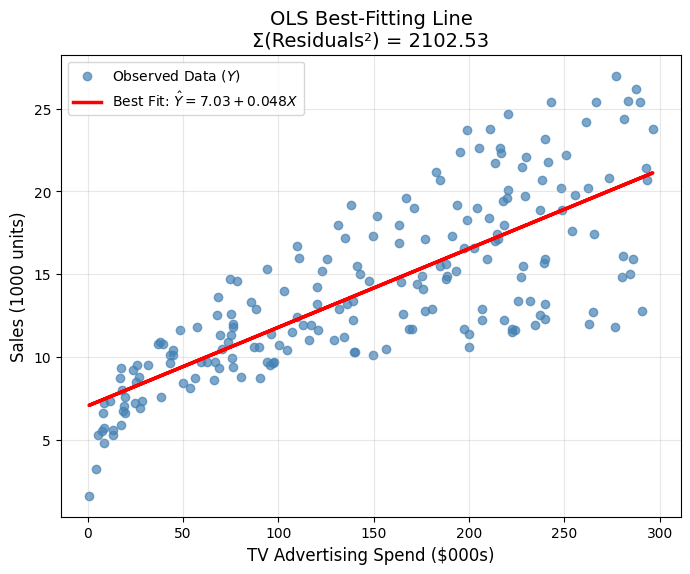

In [5]:
# --- Define X and Y ---
X = ads["TV"].values
Y = ads["sales"].values

# --- Compute the optimal betas manually ---
beta_1 = np.cov(X, Y, bias=True)[0, 1] / np.var(X)   # Cov(X, Y) / Var(X)
beta_0 = np.mean(Y) - beta_1 * np.mean(X)            # E[Y] - beta_1 * E[X]

print(f"β₀ (intercept): {beta_0:.4f}")
print(f"β₁ (slope): {beta_1:.4f}")

# --- Predicted values ---
Y_hat = beta_0 + beta_1 * X

# --- Compute residuals and SSR ---
residuals = Y - Y_hat
SSR = np.sum(residuals**2)
print(f"Sum of Squared Residuals (SSR): {SSR:.4f}")

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color="steelblue", alpha=0.7, label="Observed Data ($Y$)")
plt.plot(X, Y_hat, color="red", linewidth=2.5,
         label=fr"Best Fit: $\hat{{Y}} = {beta_0:.2f} + {beta_1:.3f}X$")

plt.xlabel("TV Advertising Spend ($000s)", fontsize=12)
plt.ylabel("Sales (1000 units)", fontsize=12)
plt.title(f"OLS Best-Fitting Line\nΣ(Residuals²) = {SSR:.2f}", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           1.47e-42
Time:                        16:05:49   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.0

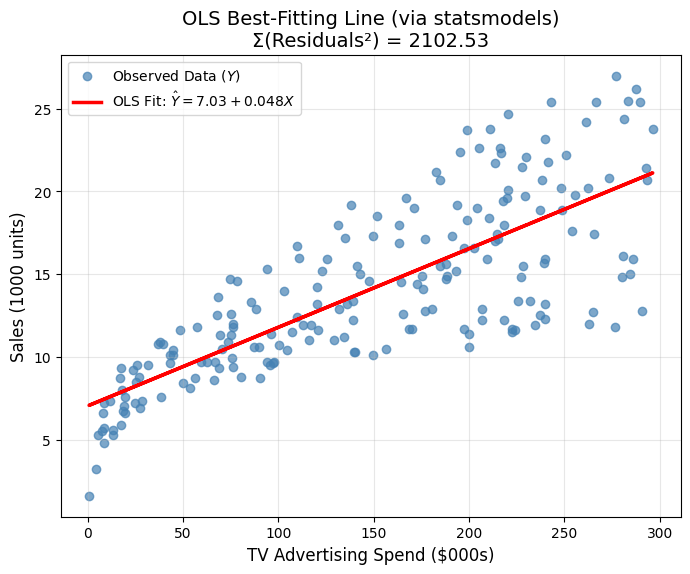

In [6]:
import statsmodels.formula.api as smf

# --- Fit regression model using statsmodels ---
model = smf.ols('sales ~ TV', data=ads).fit()

# --- Print results ---
print(model.summary())

# --- Extract coefficients ---
beta_0_pkg = model.params['Intercept']
beta_1_pkg = model.params['TV']
print(f"β₀ (intercept): {beta_0_pkg:.4f}")
print(f"β₁ (slope): {beta_1_pkg:.4f}")

# --- Predicted values ---
ads['Y_hat'] = model.fittedvalues

# --- Compute residuals and SSR ---
ads['Residuals'] = model.resid
SSR_pkg = np.sum(ads['Residuals']**2)
print(f"Sum of Squared Residuals (SSR): {SSR_pkg:.4f}")

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(ads["TV"], ads["sales"], color="steelblue", alpha=0.7, label="Observed Data ($Y$)")
plt.plot(ads["TV"], ads["Y_hat"], color="red", linewidth=2.5,
         label=fr"OLS Fit: $\hat{{Y}} = {beta_0_pkg:.2f} + {beta_1_pkg:.3f}X$")
plt.xlabel("TV Advertising Spend ($000s)", fontsize=12)
plt.ylabel("Sales (1000 units)", fontsize=12)
plt.title(f"OLS Best-Fitting Line (via statsmodels)\nΣ(Residuals²) = {SSR_pkg:.2f}", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Interpretation

**we can interpret each parameter as follows:**

| Parameter | Symbol | Estimate | Interpretation |
|------------|---------|-----------|----------------|
| **Intercept** | $ \beta_0 $ | 7.03 | When **TV advertising spending is 0**, the model predicts that **sales would still be about 7,000 units** on average. This represents the *baseline level of sales* without any TV advertising. |
| **Slope** | $ \beta_1 $ | 0.0475 | For **each additional \$1,000 spent on TV advertising**, the model predicts an **increase of approximately 47.5 units sold**, *on average*, **holding all else constant**. |
| **Sum of Squared Residuals (SSR)** | — | 2102.53 | The total *unexplained variation* in sales — i.e., the squared differences between the actual and predicted values. A smaller SSR indicates a tighter fit around the regression line. |


# Causal Regression

**The causal model setup**

We assume a linear causal model:

$$
Y(S, U) = \alpha_0 + \alpha_1 S + U
$$

where:

- $Y$ is the **outcome** (e.g., income),  
- $S$ is the **treatment or cause** (e.g., college attendance),  
- $U$ represents **all other unobserved causes** of $Y$.
- $\alpha_0$ is the **average baseline outcome** when $S = 0$ (the control or untreated group),  
- $\alpha_1$ is the **causal effect** of the treatment $S$ on $Y$ — how much the expected outcome changes when $S$ increases by 1 unit, *holding everything else constant*.

This is called the **“all-causes model”**, because $Y$ depends on both $S$ and all other factors $U$.



**The problem: we want a clean interpretation**

In causal regression, we want to interpret $ \alpha_1 $ as the **causal effect** of $S$ on $Y$.

**For that interpretation to hold, we need two things:**

1. The average of the residual term $U$ to be zero:
   $$
   \mathbb{E}[U] = 0
   $$
   (This means that, on average, the “other causes” cancel out. This is NOT ensure causality.)

2. The residual to be independent of the treatment:
   $$
   S \perp U
   $$
   (This means treatment is assigned independently of those other causes.)


**What if $\mathbb{E}[U] \neq 0$?**

If the residual has a nonzero mean (say $U$ is systematically positive or negative),
then the intercept $\alpha_0$ doesn’t truly represent the average baseline outcome.

So we redefine the intercept and residual to **re-center** $U$.

**The algebra**

Starting with the model:

$$
Y = \alpha_0 + \alpha_1 S + U
$$

and noting that $\mathbb{E}[U] \neq 0$,  
we define new parameters:

$$
\tilde{\alpha}_0 = \alpha_0 + \mathbb{E}[U], \qquad
\tilde{U} = U - \mathbb{E}[U].
$$

Substitute these back into the model:

$$
\begin{align*}
Y &= \alpha_0 + \alpha_1 S + U \\
  &= (\tilde{\alpha}_0 - \mathbb{E}[U]) + \alpha_1 S + \tilde{U} + \mathbb{E}[U] \\
  &= \tilde{\alpha}_0 + \alpha_1 S + \tilde{U}.
\end{align*}
$$

Now, by construction, $\mathbb{E}[\tilde{U}] = 0$.

So we’ve simply **redefined the intercept** to absorb the nonzero mean of $U$.



**Why we do this**

It’s just a mathematical clean-up:

- It doesn’t change the causal meaning of $ \alpha_1 $.  
- It ensures that our residual term $\tilde{U}$ has mean zero — a standard assumption that keeps the math and interpretation consistent.

After this redefinition, the model becomes:

$$
Y = \tilde{\alpha}_0 + \alpha_1 S + \tilde{U}, \qquad \mathbb{E}[\tilde{U}] = 0.
$$

### The independence assumption

For a causal interpretation, we assume that the treatment $S$ is **independent of the unobserved causes** $U$:

$$
S \perp U.
$$

This implies:

$$
\mathbb{E}[SU] = \mathbb{E}[S]\,\mathbb{E}[U].
$$

Since we also assume $\mathbb{E}[U] = 0$, it follows that:

$$
\mathbb{E}[SU] = 0.
$$

This means that the treatment $S$ is **uncorrelated** with the residual $U$ — the treatment does not depend on unobserved factors that also affect the outcome.

This is exactly the condition that **randomization** ensures in an experiment.


## Identification: Causal

For descriptive regression, we can always identify.

For causal regression, we need to make assumptions ($S \perp U$).

**Causal regression with a binary treatment**

Assume $S\in\{0,1\}$ and the linear all-causes model
$$
Y = \alpha_0 + \alpha_1 S + U,\qquad \mathbb{E}[U]=0,\quad S\perp U.
$$

Under $S\perp U$,
$$
\alpha_1=\frac{\operatorname{Cov}(S,Y)}{\operatorname{Var}(S)}.
$$

$$\operatorname{Cov}(S, Y)
= \mathbb{E}[SY] - \mathbb{E}[S]\mathbb{E}[Y]$$

**Simplify the first term**

Since $S \in \{0,1\}$:


$$
\begin{aligned}
\mathbb{E}[SY]
&= \mathbb{E}\!\left[\mathbb{E}[SY \mid S]\right] \\[4pt]
&= \mathbb{E}\!\left[S\,\mathbb{E}[Y \mid S]\right] \\[4pt]
&= \sum_{s \in \{0,1\}} s \, \mathbb{E}[Y \mid S=s] \, P(S=s) \\[4pt]
&= 0 \cdot \mathbb{E}[Y \mid S=0]\,P(S=0) + 1 \cdot \mathbb{E}[Y \mid S=1]\,P(S=1) \\[4pt]
&= \mathbb{E}[Y \mid S=1]\,P(S=1) \\[4pt]
&= \mathbb{E}[Y \mid S=1]\,p.
\end{aligned}
$$




**Simplify the second term**

We know $\mathbb{E}[S] = p$ and $\mathbb{E}[Y] = \mathbb{E}[Y\mid S=1]p + \mathbb{E}[Y\mid S=0](1-p)$:

$$
\begin{aligned}
\mathbb{E}[S]\mathbb{E}[Y]
&= p\,\mathbb{E}\!\left[\mathbb{E}[Y \mid S]\right] \\[4pt]
&= p\big(\mathbb{E}[Y \mid S=1]\,p + \mathbb{E}[Y \mid S=0]\,(1-p)\big) \\[4pt]
&= \mathbb{E}[Y \mid S=1]\,p^2 + \mathbb{E}[Y \mid S=0]\,p(1-p).
\end{aligned}
$$

Therefore,
$$
\begin{aligned}
\operatorname{Cov}(S, Y)
&= \mathbb{E}[SY] - \mathbb{E}[S]\mathbb{E}[Y] \\[6pt]
&= \big(\mathbb{E}[Y \mid S=1] \, p\big)
- \big(\mathbb{E}[Y \mid S=1]\,p^2 + \mathbb{E}[Y \mid S=0]\,p(1-p)\big)\\
&= \mathbb{E}[Y \mid S=1]\,p - \mathbb{E}[Y \mid S=1]\,p^2 - \mathbb{E}[Y \mid S=0]\,p(1-p) \\[6pt]
&= p(1-p)\big(\mathbb{E}[Y \mid S=1] - \mathbb{E}[Y \mid S=0]\big).
\end{aligned}
$$

Also, for a Bernoulli $S$, 
$$
\operatorname{Var}(S)=p(1-p).
$$

Hence,
$$
\boxed{\;\alpha_1
=\frac{\operatorname{Cov}(S,Y)}{\operatorname{Var}(S)}
=\mathbb{E}[Y\mid S=1]-\mathbb{E}[Y\mid S=0]\;}
$$

**Interpretation:** Under random assignment ($S\perp U$), the causal regression slope equals the **ATE**.
